## **Multiscale Clustering of Molecular Localizations Using MIRO**

This tutorial demonstrates how to train and apply **MIRO** for multiscale clustering of spatial point clouds from single-molecule localization microscopy (SMLM), focusing on nuclear pore complex datasets.

We show how to train **MIRO** using simulated data and then evaluate its performance on experimental SMLM datasets. In addition, the tutorial covers how to build custom data loaders tailored to the structure and format of each dataset, an essential step for applying MIRO to diverse real-world scenarios.

In [1]:
import sys
from pathlib import Path

# Ensure the library path is in sys.path
lib_path = Path.cwd().parent.resolve()

if str(lib_path) not in sys.path:
    sys.path.insert(0, str(lib_path))

import lib

### **1. Load the Data**

To begin, load the training data.

It consists of pre-generated synthetic images, each containing between 5 and 9 nuclear pore-like structures. Each structure is composed of 8 *corners* arranged symmetrically around a shared central vertex, mimicking the characteristic geometry of nuclear pore complexes.

In [2]:
import pandas as pd

training_data = pd.read_csv("data/simulated_dataset.csv")

### **2. Build the training dataset**


Next, we create the training dataset by converting each synthetic image into a graph-based representation compatible with **MIRO**. The code snippet below demonstrates how to build a custom data loader tailored to this multiscale setting.

The `MultiscaleGraphDataset` class reads each training image, computes the ground truth displacement vectors for each scale (in this case, two: the *ring* structure and the inner *corners*), and constructs a graph based on spatial connectivity. Nodes in the graph represent individual molecular localizations, while edges are defined using Delaunay triangulation and filtered by a connectivity radius.

For each image (field of view), the loader returns a `torch_geometric.data.Data` object, storing the graph structure, positional features, and scale-specific ground truth displacements. These data objects form the input to the MIRO model during training.

In [3]:
import numpy as np
import matplotlib.tri as tri
import itertools
import tqdm

import torch
from torch_geometric.transforms import AddLaplacianEigenvectorPE
from torch_geometric.data import Data


class MultiscaleGraphDataset:
    def __init__(
        self,
        training_images,
        connectivity_radius=1,
    ):
        self.training_images = training_images
        self.connectivity_radius = connectivity_radius

        self.laplacian_embedding = AddLaplacianEigenvectorPE(
            5, attr_name="x", is_undirected=True
        )

    def __call__(self):
        return self.generate_dataset()

    def generate_dataset(self):
        """Generate a dataset of graph-structured data."""
        dataset = []
        for _, df_set in tqdm.tqdm_notebook(
            self.training_images.groupby("set", sort=False),
            desc="Generating dataset",
        ):
            positions = df_set[["x", "y"]].to_numpy()

            cluster_means = self.compute_position_means(df_set, "label")
            subcluster_means = self.compute_position_means(df_set, "sublabel")

            deltas = positions - cluster_means
            subdeltas = positions - subcluster_means

            data = self.create_data_object(positions, subdeltas, deltas)
            dataset.append(data)

        return dataset

    def compute_position_means(self, df, group_col: str) -> np.ndarray:
        return (
            df.groupby(group_col)[["x", "y"]]
            .transform("mean")
            .mask(df[group_col].eq(0.0), df[["x", "y"]])
            .to_numpy()
        )

    def create_data_object(self, positions, subdeltas, deltas):
        """Create a `Data` object from positions and deltas."""
        data = Data()

        # Prepare ground truth displacements
        data.y_sub, data.y = (
            torch.tensor(subdeltas, dtype=torch.float) / self.connectivity_radius,
            torch.tensor(deltas, dtype=torch.float) / self.connectivity_radius,
        )

        # Add graph structure
        data.edge_index, data.edge_attr = self.compute_connectivity(positions)
        data.num_nodes = positions.shape[0]

        # Add positional and embedding features
        data = self.laplacian_embedding(data)
        data.x = torch.abs(data.x)
        data.position = torch.tensor(positions, dtype=torch.float)

        return data

    def compute_connectivity(self, positions):
        """Compute the connectivity graph and edge attributes."""
        delaunay = tri.Triangulation(positions[:, 0], positions[:, 1])
        edges = self.extract_edges(delaunay.triangles)

        distances, displacements = self.compute_edge_metrics(edges, positions)
        valid_mask = distances < self.connectivity_radius

        edges = edges[valid_mask]
        distances = distances[valid_mask, None]
        displacements = displacements[valid_mask]

        edges, displacements, distances = self.make_graph_undirected(
            edges, displacements, distances
        )

        edge_index, edge_attr = self.format_edges_and_attributes(
            edges, displacements, distances
        )
        return edge_index, edge_attr

    @staticmethod
    def extract_edges(triangles):
        """Extract edges from triangles."""
        edges = [
            np.array(list(itertools.combinations(triangle, r=2)))[[1, 0, 2]]
            for triangle in triangles
        ]
        return np.concatenate(edges, axis=0)

    @staticmethod
    def compute_edge_metrics(edges, positions):
        """Compute displacements and distances for edges."""
        displacements = positions[edges[:, 0]] - positions[edges[:, 1]]
        distances = np.linalg.norm(displacements, axis=1)
        return distances, displacements

    @staticmethod
    def make_graph_undirected(edges, displacements, distances):
        """Ensure the graph is undirected by mirroring edges."""
        edges = np.concatenate([edges, edges[:, [1, 0]]], axis=0)
        displacements = np.concatenate([displacements, -displacements], axis=0)
        distances = np.concatenate([distances, distances], axis=0)

        # Remove duplicate edges
        unique_edges, indices = np.unique(edges, axis=0, return_index=True)
        return unique_edges, displacements[indices], distances[indices]

    def format_edges_and_attributes(self, edges, displacements, distances):
        """Format edges and their attributes for PyTorch Geometric."""
        edge_index = torch.tensor(edges.T, dtype=torch.long)
        edge_attr = (
            torch.cat(
                [
                    torch.tensor(displacements, dtype=torch.float),
                    torch.tensor(distances, dtype=torch.float),
                ],
                dim=1,
            )
            / self.connectivity_radius
        )
        return edge_index, edge_attr

Now, instantiate the dataset builder and generate the training dataset.

In [4]:
builder = MultiscaleGraphDataset(
    training_data,
    connectivity_radius=0.2,
)
training_dataset = builder()

C:\Users\bertg\AppData\Local\Temp\ipykernel_45872\3279767754.py:30: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for _, df_set in tqdm.tqdm_notebook(


Generating dataset:   0%|          | 0/1001 [00:00<?, ?it/s]

Let’s take a closer look at one of the training samples.

The colormap in the labeled scatter plot represents the magnitude of the **displacement vectors** from each node to its assigned cluster center, across both spatial scales.

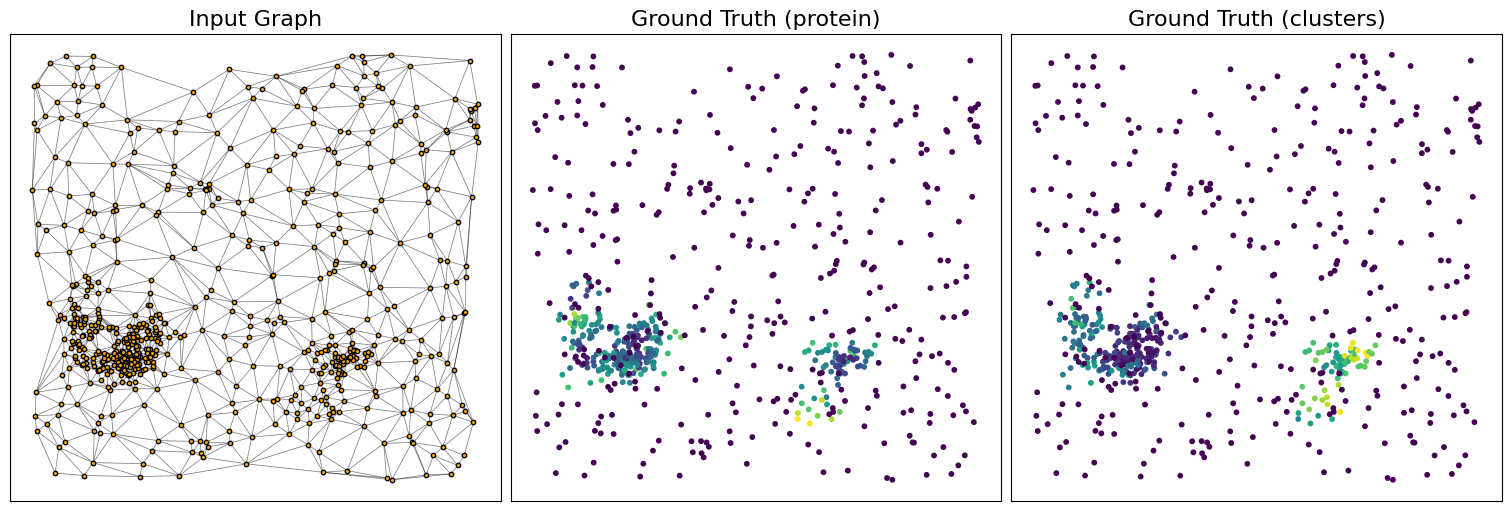

In [5]:
import numpy as np
import random

import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

def plot_training_data(data, figsize=(15, 5), titles=None):
    pos = data["position"]        
    edges = data["edge_index"].T  
    norms = [                    
        None,
        np.linalg.norm(data["y"], axis=1),
        np.linalg.norm(data["y_sub"], axis=1),
    ]

    titles = titles or [
        "Input Graph",
        "Ground Truth (protein)",
        "Ground Truth (clusters)",
    ]

    fig, axes = plt.subplots(1, 3, figsize=figsize, constrained_layout=True)

    for i, ax in enumerate(axes):
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(titles[i], fontsize=16)

        if i == 0:
            segments = pos[edges]
            lc = LineCollection(segments, colors="black",
                                linewidths=0.5, alpha=0.3)
            ax.add_collection(lc)
            ax.scatter(pos[:, 0], pos[:, 1],
                       s=10, c="orange", edgecolors="black", zorder=2)
        else:
            im = ax.scatter(pos[:, 0], pos[:, 1],
                            c=norms[i], s=10)

    return fig, axes


idx = random.randrange(len(training_dataset))
fig, axes = plot_training_data(training_dataset[idx])
plt.show()

### **3. Create the model**


Now, instantiate **MIRO** using the configuration that matches the training data. 

The model is initialized with a set of key parameters: the number of output features (in this case, 2 for the predicted *x* and *y* displacements), the connectivity radius used to construct the input graphs (which should match the one used during augmentation), the number of recurrent message-passing iterations to apply on the input graphs (set to 20 by default), and `cutoff_iterations`, which defines how many of those iterations are run at the smaller spatial scale before switching to the larger one.

In this example, the total 20 recurrent iterations are split into the first 10 focused on the corner-scale structures, and the remaining 10 on the rings. 

In [6]:
import deeplay as dl

clusterer = dl.mMIRO(
    num_outputs=2,  # Number of output features (e.g., x, y displacements)
    connectivity_radius=builder.connectivity_radius,  # Radius for graph connectivity (matches dataset)
    num_iterations=20,  # Number of iterations for graph processing
    cutoff_iterations=10, # Number of iterations at the smaller scale before switching to the larger one
)
clusterer = clusterer.create()

print(clusterer)

mMIRO(
  (model): RecurrentMessagePassingModel(
    (encoder): Parallel(
      (0-1): 2 x MultiLayerPerceptron(
        (blocks): LayerList(
          (0): LinearBlock(
            (layer): LazyLinear(in_features=0, out_features=256, bias=True)
            (activation): Identity()
          )
        )
      )
    )
    (backbone): RecurrentGraphBlock(
      (combine): CatDictElements()
      (layer): Sequential(
        (0): Parallel(
          (0-1): 2 x MultiLayerPerceptron(
            (blocks): LayerList(
              (0): LinearBlock(
                (layer): LazyLinear(in_features=0, out_features=256, bias=True)
                (activation): Identity()
              )
            )
          )
        )
        (1): MessagePassingNeuralNetwork(
          (blocks): LayerList(
            (0): TransformPropagateUpdate(
              (transform): Transform(
                (combine): Cat()
                (layer): LazyLinear(in_features=0, out_features=256, bias=True)
            

### **4. Train the model**


Set up the data loaders and configure the training parameters.

In [21]:
from torch_geometric.data import DataLoader

train_loader = DataLoader(
    dataset=training_dataset,  # The dataset to be loaded
    batch_size=4,  # Number of samples per batch
    shuffle=True,  # Shuffle the dataset at every epoch
)

# Initialize the trainer
trainer = dl.Trainer(max_epochs=30)  # Maximum number of training epochs

C:\Users\bertg\AppData\Local\Temp\ipykernel_37460\2937598324.py:3: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  train_loader = DataLoader(
c:\Users\bertg\OneDrive\Escritorio\TFG\env_tfg\Lib\site-packages\lightning\pytorch\trainer\connectors\logger_connector\logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default


Finally, train **MIRO**. 

Alternatively, you can load a pre-trained model by setting `train_model = False`.

In [7]:
import torch

train_model = False

if train_model:
    trainer.fit(
        clusterer,  # The MIRO model to be trained
        train_loader,  # The DataLoader providing the training data
    )
else:
    state = torch.load("models/checkpoint.pt", map_location=torch.device("cpu")) # Load pre-trained model weights
    clusterer.load_state_dict(state)
    clusterer.to("cpu")
    clusterer.eval()

### **5. Test the model**


Once training is complete, it’s time to evaluate **MIRO** on experimental data obtained from SMLM imaging of Nup96-nMaple in fixed U2OS cells ([Thevathasan, J.V. et al. *Nat Methods* (2019)](https://www.nature.com/articles/s41592-019-0574-9)).


In [8]:
test_data = pd.read_csv("data/simulated_dataset.csv")

Before applying **MIRO** to the validation dataset, we normalize the localization coordinates to ensure that the spatial scale of the structures in the test data matches that of the training data.

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_comparison(csv_path, run_id):
    df = pd.read_csv(csv_path)
    subset = df[df["set"] == run_id]

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    # --- Imagen 1: puntos en negro ---
    axes[0].scatter(
        subset["x"],
        subset["y"],
        s=3,
        c="black",
        alpha=0.6
    )
    axes[0].set_title(f"Run {run_id} (puntos)")
    axes[0].set_aspect("equal")

    # --- Imagen 2: coloreado por cluster real ---
    axes[1].scatter(
        subset["x"],
        subset["y"],
        s=5,
        c=subset["label"],
        cmap="tab20",
        alpha=0.7
    )
    axes[1].set_title(f"Clusters reales (run {run_id})")
    axes[1].set_aspect("equal")

    plt.tight_layout()
    plt.show()


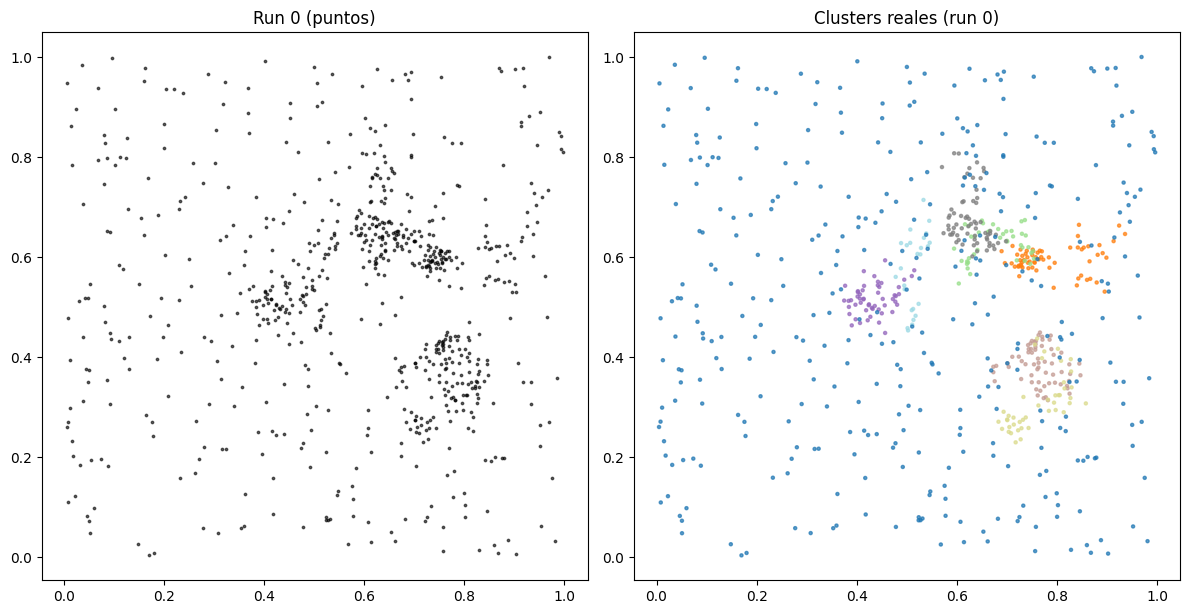

In [49]:
plot_comparison("data/simulated_dataset.csv", run_id=0)

Now that the test data has been normalized, we proceed to create the graph representation required by **MIRO**. We use the `compute_test_graph` function and set `norm=False` to avoid re-normalizing the data.

Note that this step may take a few minutes, depending on the size of the dataset. Alternatively, a pre-computed graph can be loaded by setting `use_precomputed_graph=True`.

In [10]:
use_precomputed_graph = False

if use_precomputed_graph:
    test_graph = torch.load("data/test_graph.pt")
else:
    test_graph = lib.compute_test_graph(
        test_data,
        builder=builder,
        norm=False,
    )

In [11]:
torch.save(test_graph, "data/test_graph_new.pt")

We now apply **MIRO** to the test graph to obtain clustering results at multiple spatial scales.

For each scale, we specify the iteration from which to extract node embeddings (`from_iter`), along with the DBSCAN parameters (`eps` and `min_samples`) used to define clusters in the learned representation space.

We also provide a `scaling` factor to convert the normalized coordinates back to physical units (nanometers) before clustering.

The `clusterer.clustering` method applies **MIRO** to the test graph, transforms the node features through the trained model, and performs DBSCAN clustering on the resulting representation. The resulting cluster labels for each scale are stored in `test_data` under `clustering_corners` and `clustering_rings`, respectively.


In [12]:
import pandas as pd
import torch
import numpy as np

def process_first_300_runs(test_data, clusterer, builder, metadata, scaling):
    """
    Processa només les 300 primeres runs del dataset.
    Construeix el graf per cada run, aplica MIRO i concatena els resultats.
    """

    # Seleccionar només les 300 primeres runs
    runs = sorted(test_data["set"].unique())[:300]

    all_results = []

    for run_id in runs:
        print(f"Processant run {run_id}...")

        subset = test_data[test_data["set"] == run_id].copy()

        try:
            # Construcció del graf per aquest run
            graph = lib.compute_test_graph(
                subset,
                builder=builder,
                norm=False,
            )

            # Aplicar MIRO per cada escala
            for scale_name, params in metadata.items():
                subset[f"clustering_{scale_name}"] = clusterer.clustering(
                    graph,
                    scaling=scaling,
                    **params
                )

            all_results.append(subset)

        except RuntimeError as e:
            print(f" Run {run_id} saltada per falta de memòria ({e})")
            continue

    # Concatenar tots els resultats
    final_df = pd.concat(all_results, ignore_index=True)
    return final_df


In [13]:
clusterer.eval()
clusterer.to("cuda" if torch.cuda.is_available() else "cpu")

metadata = {
    "protein": {"from_iter": 9,  "eps": 4,  "min_samples": 4},
    "cluster":   {"from_iter": 19, "eps": 30, "min_samples": 16},
}

scaling = np.array([2000, 2000])

final_df = process_first_300_runs(
    test_data=test_data,
    clusterer=clusterer,
    builder=builder,
    metadata=metadata,
    scaling=scaling
)

final_df.to_csv("results_miro_300_runs.csv", index=False)

Processant run -1...
Processant run 0...
Processant run 1...
Processant run 2...
Processant run 3...
Processant run 4...
Processant run 5...
Processant run 6...
Processant run 7...
Processant run 8...
Processant run 9...
Processant run 10...
Processant run 11...
Processant run 12...
Processant run 13...
Processant run 14...
Processant run 15...
Processant run 16...
Processant run 17...
Processant run 18...
Processant run 19...
Processant run 20...
Processant run 21...
Processant run 22...
Processant run 23...
Processant run 24...
Processant run 25...
Processant run 26...
Processant run 27...
Processant run 28...
Processant run 29...
Processant run 30...
Processant run 31...
Processant run 32...
Processant run 33...
Processant run 34...
Processant run 35...
Processant run 36...
Processant run 37...
Processant run 38...
Processant run 39...
Processant run 40...
Processant run 41...
Processant run 42...
Processant run 43...
Processant run 44...
Processant run 45...
Processant run 46...
Pr

Finally, we can visualize the clustering results produced by **MIRO**. 

The following code selects a region of interest from the test dataset and plots the cluster assignments for the `corners` and `rings` scales side by side. Each point represents a localization, and points belonging to the same cluster are shown in the same randomly assigned color. Background points are shown in gray with reduced opacity.

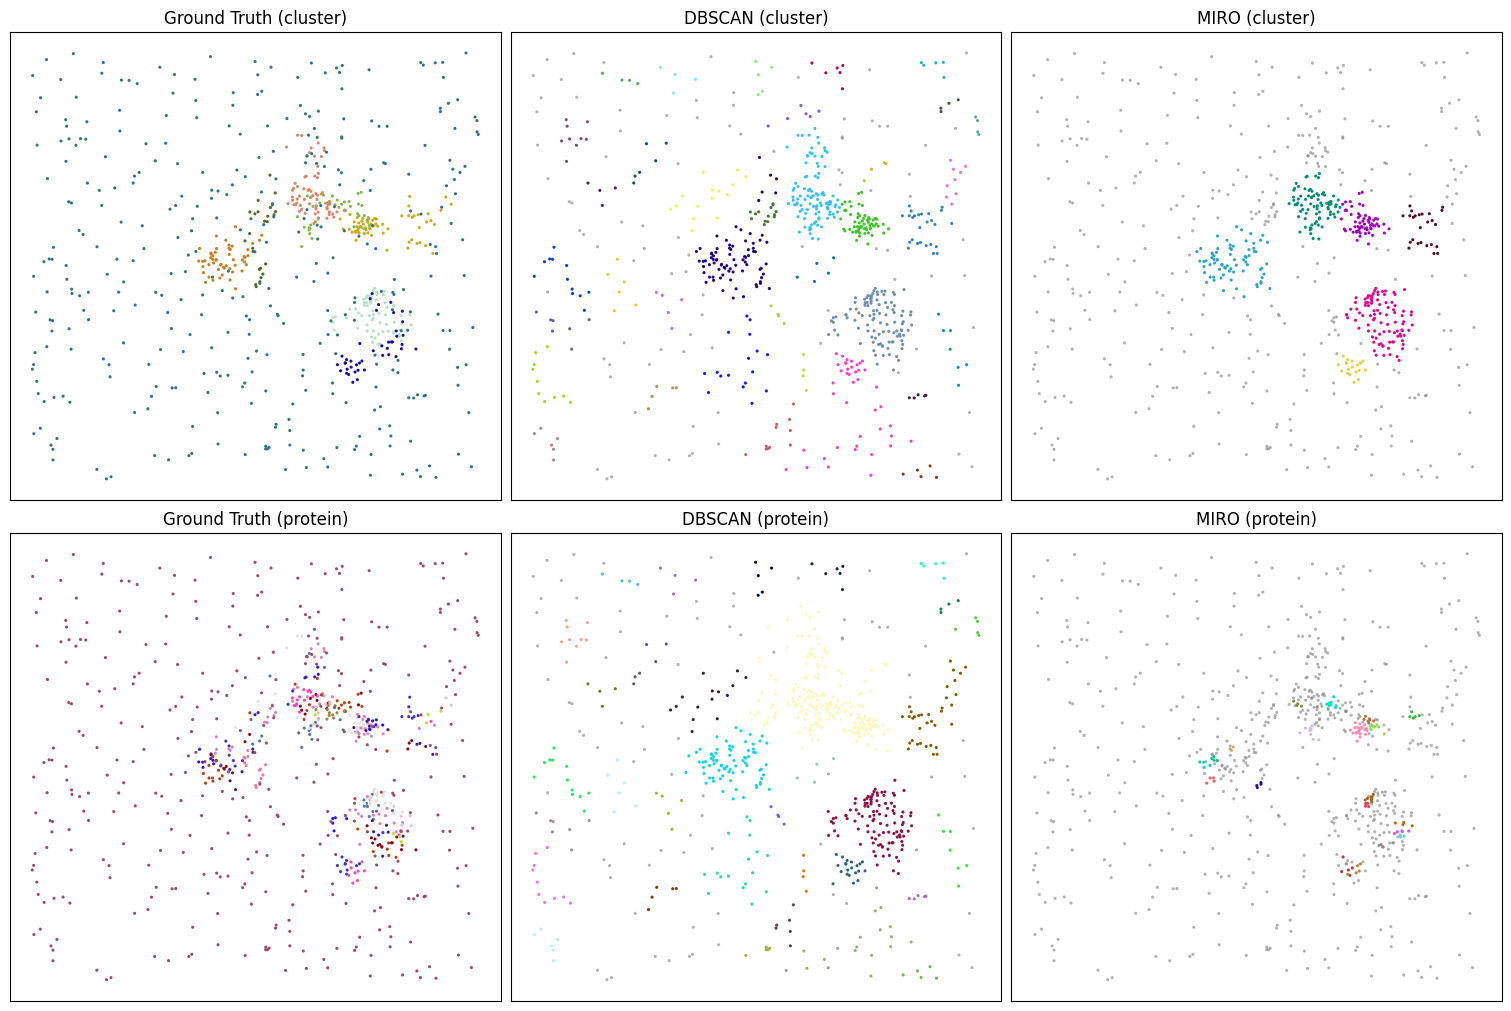

In [14]:
clusterer.eval()
clusterer.to("cuda" if torch.cuda.is_available() else "cpu")

# --- Filtrar només el primer run ---
test_data_0 = test_data[test_data["set"] == 0].copy()

# --- Construir grafo del run 0 ---
graph = lib.compute_test_graph(
    test_data_0,
    builder=builder,
    norm=False,
)

# --- Executar MIRO per cluster i protein ---
# metadata = {"cluster": {...}, "protein": {...}}
for scale_name, params in metadata.items():
    test_data_0[f"clustering_{scale_name}"] = clusterer.clustering(
        graph,
        scaling=scaling,
        **params
    )

# --- OBTENIR EMBEDDINGS MIRO PER DBSCAN ---
embedding_cluster = clusterer.squeeze(
    graph,
    from_iter=metadata["cluster"]["from_iter"]
)

embedding_protein = clusterer.squeeze(
    graph,
    from_iter=metadata["protein"]["from_iter"]
)

# --- DBSCAN SOBRE EMBEDDINGS (escala cluster i proteina) ---
from sklearn.cluster import DBSCAN

test_data_0["dbscan_cluster"] = DBSCAN(
    eps=0.05,
    min_samples=4
).fit_predict(embedding_cluster)

test_data_0["dbscan_protein"] = DBSCAN(
    eps=0.05,
    min_samples=4
).fit_predict(embedding_protein)

# --- Definir el crop (zoom automàtic sobre un cluster GT) ---
cluster0 = test_data_0[test_data_0["label"] == 0]
mask = (
    test_data_0["x"].between(cluster0["x"].min(), cluster0["x"].max())
    &
    test_data_0["y"].between(cluster0["y"].min(), cluster0["y"].max())
)
crop = test_data_0.loc[mask]

# --- FIGURA 2x3 ---
fig, axes = plt.subplots(2, 3, figsize=(15, 10), constrained_layout=True)

scales = ["cluster", "protein"]

# Diccionari de columnes per cada escala
pred_cols = {
    "cluster": {
        "gt": "label",
        "dbscan": "dbscan_cluster",
        "miro": "clustering_cluster",
    },
    "protein": {
        "gt": "sublabel",
        "dbscan": "dbscan_protein",
        "miro": "clustering_protein",
    }
}

def plot_panel(ax, df, col):
    groups = df.groupby(col, sort=False)

    for label, group in groups:
        if label == -1:
            color, alpha = "gray", 0.6
        else:
            color = np.random.rand(3)
            alpha = 1.0

        ax.scatter(
            group["x"],
            group["y"],
            s=5,
            color=color,
            alpha=alpha,
            edgecolors="none",
        )

    ax.set_xticks([])
    ax.set_yticks([])

# --- Dibuixar la figura ---
for row, scale in enumerate(scales):
    cols = pred_cols[scale]

    # Ground Truth
    plot_panel(axes[row, 0], crop, col=cols["gt"])
    axes[row, 0].set_title(f"Ground Truth ({scale})")

    # DBSCAN
    plot_panel(axes[row, 1], crop, col=cols["dbscan"])
    axes[row, 1].set_title(f"DBSCAN ({scale})")

    # MIRO
    plot_panel(axes[row, 2], crop, col=cols["miro"])
    axes[row, 2].set_title(f"MIRO ({scale})")

plt.show()


In [15]:
df_eval = test_data_0.copy()
df_eval["index"] = df_eval["label"]  # GT cluster
df_eval["clustering-predictions"] = df_eval["clustering_cluster"]

results_miro_cluster = lib.calculate_few_metrics_for_experiments(df_eval)

print("Metrics for MIRO clustering (cluster scale):", results_miro_cluster)


Metrics for MIRO clustering (cluster scale):    experiment             class_names  ARI_values  ARI_clust_values  \
0           0  clustering-predictions    0.667266          0.564471   

   ARI_dagger_values  AMI_values  JIc_values  RMSRE_N_values  \
0           0.487184    0.621742    0.857143        5.504652   

   RMSE_centr_values  
0           0.215253  


In [16]:
df_eval = test_data_0.copy()
df_eval["index"] = df_eval["label"]  # GT cluster
df_eval["clustering-predictions"] = df_eval["dbscan_cluster"]

results_dbscan_cluster = lib.calculate_few_metrics_for_experiments(df_eval)
print("Metrics for DBSCAN clustering (cluster scale):", results_dbscan_cluster)

Metrics for DBSCAN clustering (cluster scale):    experiment             class_names  ARI_values  ARI_clust_values  \
0           0  clustering-predictions    0.140272          0.629137   

   ARI_dagger_values  AMI_values  JIc_values  RMSRE_N_values  \
0           0.676775    0.432586    0.128205        0.548981   

   RMSE_centr_values  
0           0.186146  


In [17]:
df_eval = test_data_0.copy()
df_eval["index"] = df_eval["sublabel"]  # GT proteina
df_eval["clustering-predictions"] = df_eval["clustering_protein"]

results_miro_protein = lib.calculate_few_metrics_for_experiments(df_eval)
print("Metrics for MIRO clustering (protein scale):", results_miro_protein)

Metrics for MIRO clustering (protein scale):    experiment             class_names  ARI_values  ARI_clust_values  \
0           0  clustering-predictions    0.208489          0.006742   

   ARI_dagger_values  AMI_values  JIc_values  RMSRE_N_values  \
0                0.0    0.172439        0.65        3.954127   

   RMSE_centr_values  
0           0.322023  


In [18]:
df_eval = test_data_0.copy()
df_eval["index"] = df_eval["sublabel"]  # GT proteina
df_eval["clustering-predictions"] = df_eval["dbscan_protein"]

results_dbscan_protein = lib.calculate_few_metrics_for_experiments(df_eval)
print("Metrics for DBSCAN clustering (protein scale):", results_dbscan_protein)

Metrics for DBSCAN clustering (protein scale):    experiment             class_names  ARI_values  ARI_clust_values  \
0           0  clustering-predictions   -0.052537          0.047967   

   ARI_dagger_values  AMI_values  JIc_values  RMSRE_N_values  \
0           0.417111    0.145738    0.179487        2.042914   

   RMSE_centr_values  
0           0.382986  


In [19]:
results_dbscan = []
results_miro = []

first100 = sorted(test_data["set"].unique())[:50]

for s in first100:
    print(f"\n=== RUN {s} ===")
    df_run = test_data[test_data["set"] == s].copy()

    # ============================
    # DBSCAN ADAPTATIU
    # ============================
    if s == -1 or s == first100[0]:
        eps_value = 4
        print("→ eps especial per al primer run:", eps_value)
    else:
        eps_value = 0.05

    db_labels = DBSCAN(eps=eps_value, min_samples=4).fit_predict(df_run[["x","y"]])
    df_run["dbscan_cluster"] = db_labels
    df_run["dbscan_protein"] = db_labels

    # ============================
    # MIRO
    # ============================
    graph = lib.compute_test_graph(df_run, builder=builder, norm=False)

    for scale_name, params in metadata.items():
        df_run[f"clustering_{scale_name}"] = clusterer.clustering(
            graph,
            scaling=scaling,
            **params
        )

    # ============================
    # DBSCAN metrics (cluster)
    # ============================
    if len(np.unique(df_run["dbscan_cluster"])) > 1:
        df_eval = df_run.copy()
        df_eval["index"] = df_eval["label"]
        df_eval["clustering-predictions"] = df_eval["dbscan_cluster"]

        res = lib.calculate_few_metrics_for_experiments(df_eval)
        res["method"] = "DBSCAN"
        res["scale"] = "cluster"
        res["run"] = s
        results_dbscan.append(res)
    else:
        print("DBSCAN cluster → només 1 clúster → saltat")

    # ============================
    # MIRO metrics (cluster)
    # ============================
    if len(np.unique(df_run["clustering_cluster"])) > 1:
        df_eval = df_run.copy()
        df_eval["index"] = df_eval["label"]
        df_eval["clustering-predictions"] = df_eval["clustering_cluster"]

        res = lib.calculate_few_metrics_for_experiments(df_eval)
        res["method"] = "MIRO"
        res["scale"] = "cluster"
        res["run"] = s
        results_miro.append(res)
    else:
        print("MIRO cluster → només 1 clúster → saltat")

    # ============================
    # MIRO metrics (protein)
    # ============================
    if len(np.unique(df_run["clustering_protein"])) > 1:
        df_eval = df_run.copy()
        df_eval["index"] = df_eval["sublabel"]
        df_eval["clustering-predictions"] = df_eval["clustering_protein"]

        res = lib.calculate_few_metrics_for_experiments(df_eval)
        res["method"] = "MIRO"
        res["scale"] = "protein"
        res["run"] = s
        results_miro.append(res)
    else:
        print("MIRO protein → només 1 clúster → saltat")

# ============================
# Unir resultats
# ============================
results_df = pd.concat(results_dbscan, ignore_index=True) if results_dbscan else pd.DataFrame()
results_df2 = pd.concat(results_miro, ignore_index=True) if results_miro else pd.DataFrame()

print("\n=== RESULTATS DBSCAN ===")
print(results_df)

print("\n=== RESULTATS MIRO ===")
print(results_df2)



=== RUN -1 ===
→ eps especial per al primer run: 4
DBSCAN cluster → només 1 clúster → saltat
MIRO cluster → només 1 clúster → saltat
MIRO protein → només 1 clúster → saltat

=== RUN 0 ===

=== RUN 1 ===

=== RUN 2 ===

=== RUN 3 ===

=== RUN 4 ===

=== RUN 5 ===

=== RUN 6 ===

=== RUN 7 ===

=== RUN 8 ===

=== RUN 9 ===

=== RUN 10 ===

=== RUN 11 ===

=== RUN 12 ===

=== RUN 13 ===

=== RUN 14 ===

=== RUN 15 ===

=== RUN 16 ===

=== RUN 17 ===

=== RUN 18 ===

=== RUN 19 ===

=== RUN 20 ===

=== RUN 21 ===

=== RUN 22 ===

=== RUN 23 ===

=== RUN 24 ===

=== RUN 25 ===

=== RUN 26 ===

=== RUN 27 ===

=== RUN 28 ===

=== RUN 29 ===

=== RUN 30 ===

=== RUN 31 ===

=== RUN 32 ===

=== RUN 33 ===

=== RUN 34 ===

=== RUN 35 ===

=== RUN 36 ===

=== RUN 37 ===

=== RUN 38 ===

=== RUN 39 ===

=== RUN 40 ===

=== RUN 41 ===

=== RUN 42 ===

=== RUN 43 ===

=== RUN 44 ===

=== RUN 45 ===

=== RUN 46 ===

=== RUN 47 ===

=== RUN 48 ===

=== RESULTATS DBSCAN ===
    experiment            

In [20]:
paired = results_df.merge(
    results_df2,
    on=["experiment", "scale"],
    suffixes=("_dbscan", "_miro")
)


In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_boxplot_sidepoints_scaled(miro, db, metric_name, p_value):

    sns.set_style("white")

    data = pd.DataFrame({
        "valor": list(miro) + list(db),
        "Algoritme": ["MIRO"] * len(miro) + ["DBSCAN"] * len(db)
    })

    plt.figure(figsize=(6, 4))  #  més compacte per fila

    colors = {
        "MIRO": "#4C72B0",
        "DBSCAN": "#55A868"
    }

    ax = plt.gca()

    # ============================
    #  POSICIONS COMPACTES
    # ============================
    x_positions = {"MIRO": 0, "DBSCAN": 0.6}
    offset = -0.22  # violin + punts a l'esquerra

    # ============================
    #  BOXPLOT (matplotlib)
    # ============================
    box = ax.boxplot(
        [
            data[data["Algoritme"] == "MIRO"]["valor"],
            data[data["Algoritme"] == "DBSCAN"]["valor"]
        ],
        positions=[x_positions["MIRO"], x_positions["DBSCAN"]],
        widths=0.16,
        patch_artist=True,
        showfliers=False
    )

    # colors boxplot
    for patch, alg in zip(box['boxes'], ["MIRO", "DBSCAN"]):
        patch.set_facecolor(colors[alg])
        patch.set_alpha(0.6)

    # mediana en vermell
    for median in box['medians']:
        median.set_color("#E57373")
        median.set_linewidth(2.2)

    # ============================
    #  VIOLIN DESPLAÇAT
    # ============================
    for alg in ["MIRO", "DBSCAN"]:
        vals = data[data["Algoritme"] == alg]["valor"]

        parts = ax.violinplot(
            vals,
            positions=[x_positions[alg] + offset],
            widths=0.18,
            showmeans=False,
            showmedians=False,
            showextrema=False
        )

        for pc in parts['bodies']:
            pc.set_facecolor(colors[alg])
            pc.set_alpha(0.35)

    # ============================
    #  PUNTS (alineats amb violin)
    # ============================
    for alg in ["MIRO", "DBSCAN"]:
        vals = data[data["Algoritme"] == alg]["valor"]

        jitter = np.random.uniform(-0.035, 0.035, size=len(vals))
        x = np.ones(len(vals)) * (x_positions[alg] + offset) + jitter

        plt.scatter(
            x, vals,
            color=colors[alg],
            alpha=0.6,
            s=26,
            zorder=3
        )

    # ============================
    #  SIGNIFICÀNCIA
    # ============================
    y_max = data["valor"].max()
    y_min = data["valor"].min()
    h = (y_max - y_min) * 0.03

    plt.plot(
        [x_positions["MIRO"], x_positions["MIRO"],
         x_positions["DBSCAN"], x_positions["DBSCAN"]],
        [y_max + h, y_max + 2*h, y_max + 2*h, y_max + h],
        color="black", linewidth=1.2
    )

    if p_value < 0.0001:
        stars = "****"
    elif p_value < 0.001:
        stars = "***"
    elif p_value < 0.01:
        stars = "**"
    elif p_value < 0.05:
        stars = "*"
    else:
        stars = "ns"

    plt.text(
        (x_positions["MIRO"] + x_positions["DBSCAN"]) / 2,
        y_max + 2.3*h,
        stars,
        ha="center",
        fontsize=16,
        fontweight="bold"
    )

    # ============================
    #  PANEL LETTER
    # ============================
    letter_map = {
        "ARI_c_values": "A",
        "ARI_dagger_values": "B",
        "AMI_values": "C",
        "JIc_values": "A",
        "RMSRE_N_values": "B",
        "RMSE_centr_values": "C"
    }

    letter = letter_map.get(metric_name, "")

    plt.text(
        0.02, 0.95, letter,
        transform=plt.gcf().transFigure,
        fontsize=18,
        fontweight="bold",
        va="top",
        ha="left"
    )

    # ============================
    #  LÍMITS Y
    # ============================
    if metric_name == "RMSE_centr_values":
        plt.ylim(y_min -0.5, y_max + 0.5)
    else:
        plt.ylim(0, y_max + 0.1)

    # ============================
    #  EIX X CORRECTE
    # ============================
    plt.xticks(
        [x_positions["MIRO"], x_positions["DBSCAN"]],
        ["MIRO", "DBSCAN"]
    )

    plt.title(f"{metric_name} (p = {p_value:.3g})", fontsize=18, pad=15)
    plt.xlabel("")
    plt.xlim(-0.35, 0.75)
    plt.tight_layout()
    plt.show()


=== ARI_clust_values ===
n = 49
Mean DBSCAN = 0.3011
Mean MIRO   = 0.5506
t-statistic = 8.7686
p-value one-sided (MIRO > DBSCAN) = 7.78798e-12
Conclusion: significant difference.


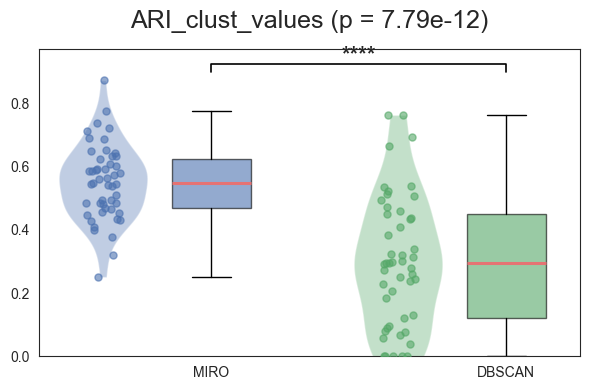


=== ARI_dagger_values ===
n = 49
Mean DBSCAN = 0.8571
Mean MIRO   = 0.4966
t-statistic = -26.6733
p-value two-sided (DBSCAN > MIRO) = 1.95084e-30
Conclusion: significant difference.


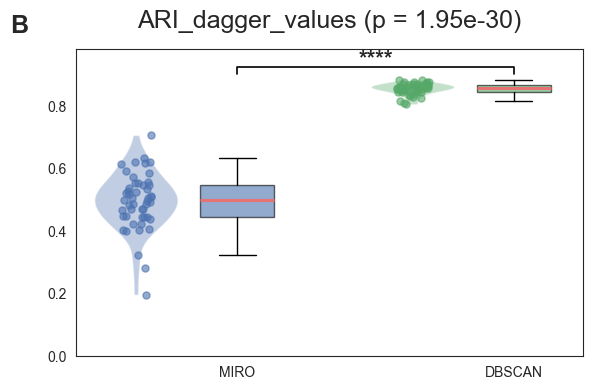


=== AMI_values ===
n = 49
Mean DBSCAN = 0.3193
Mean MIRO   = 0.5911
t-statistic = 20.8633
p-value one-sided (MIRO > DBSCAN) = 5.11558e-26
Conclusion: significant difference.


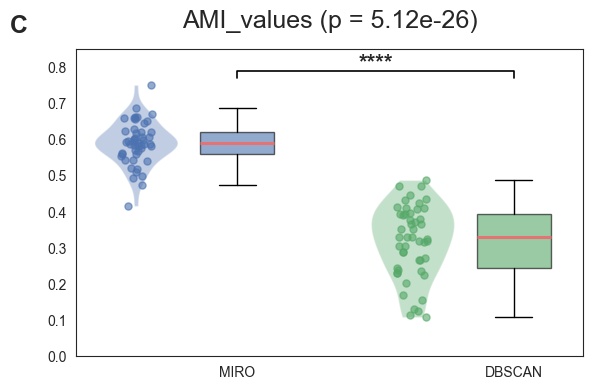


=== JIc_values ===
n = 49
Mean DBSCAN = 0.0700
Mean MIRO   = 0.5768
t-statistic = 30.2955
p-value one-sided (MIRO > DBSCAN) = 3.02676e-33
Conclusion: significant difference.


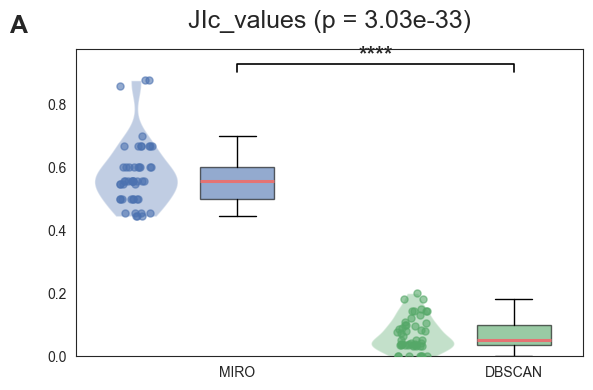


=== RMSRE_N_values ===
n = 49
Mean DBSCAN = 1.2657
Mean MIRO   = 0.5976
t-statistic = -3.2062
p-value two-sided (DBSCAN > MIRO) = 0.00239419
Conclusion: significant difference.


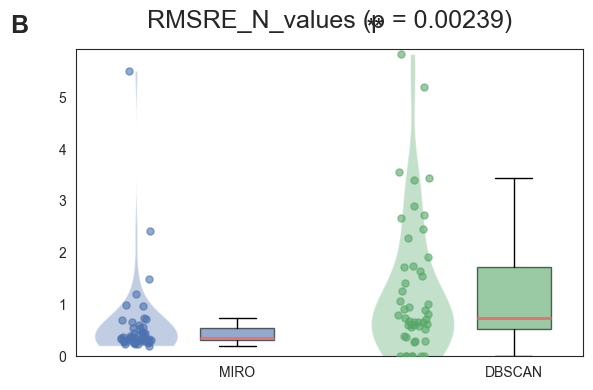


=== RMSE_centr_values ===
n = 49
Mean DBSCAN = 0.1504
Mean MIRO   = 0.1851
t-statistic = 2.8182
p-value one-sided (MIRO > DBSCAN) = 0.003497
Conclusion: significant difference.


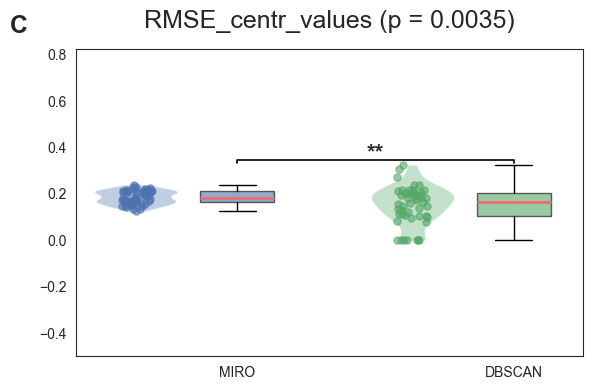

In [25]:
from scipy.stats import ttest_rel

metrics = [ "ARI_clust_values", "ARI_dagger_values", "AMI_values", "JIc_values", "RMSRE_N_values", "RMSE_centr_values"]

for metric in metrics:
    db = paired[f"{metric}_dbscan"].to_numpy()
    miro = paired[f"{metric}_miro"].to_numpy()

    # paired t-test
    t_stat, p_two_sided = ttest_rel(miro, db)

    if t_stat > 0:
        p_value = p_two_sided / 2
        tail = "one-sided (MIRO > DBSCAN)"
    else:
        p_value = p_two_sided
        tail = "two-sided (DBSCAN > MIRO)"

    print(f"\n=== {metric} ===")
    print(f"n = {len(db)}")
    print(f"Mean DBSCAN = {db.mean():.4f}")
    print(f"Mean MIRO   = {miro.mean():.4f}")
    print(f"t-statistic = {t_stat:.4f}")
    print(f"p-value {tail} = {p_value:.6g}")

    if p_value < 0.05:
        print("Conclusion: significant difference.")
    else:
        print("Conclusion: no significant difference.")

    plot_boxplot_sidepoints_scaled(miro, db, metric, p_value)
